Setup

In [1]:
import os
import glob
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

IMG_H, IMG_W = 100, 100

MODEL_PATH = "rps_gray100_savedmodelv3.keras"
BATCH            = 64
EPOCHS           = 80

TRAIN_IMG_FOLDER = "rps_manual_capture/*_*.png"
LABEL_TO_ID_DICT = {"rock": 0, "paper": 1, "scissors": 2}
ID_TO_LABEL_DICT = {0 : "rock", 1: "paper", 2: "scissors"}

AUGMENT_PER_SOURCE_IMG = 200 #Generate this number of augmented images per original image
AUGMENT_PER_TEST_IMG = 100 #Generate this number of augmented images per original image
TRAIN_TEST_SPLIT = 0.2

2026-03-13 11:40:56.482861: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-13 11:40:56.483058: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 11:40:56.510886: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 11:40:57.140695: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

Seed the RNGs

In [2]:
SEED = 123
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Load Images as Numpy Arrays

In [3]:
def pil_to_gray_array(img):
    img = img.convert("L")
    img = img.resize((IMG_W, IMG_H), Image.BILINEAR)
    img_tensor = np.array(img, dtype=np.uint8)
    img_tensor = (img_tensor - 128.0)/128.0
    return img_tensor[:, :, np.newaxis] #New axis for color channel

In [4]:
sources = {"rock" : [], "paper" : [], "scissors" : []}   #dictionary to put PIL images as lists with labels as keys

for filename in glob.glob(TRAIN_IMG_FOLDER):
    try:
        label_str = os.path.splitext(os.path.basename(filename))[0].split("_")[-1] #Get the label at the end of the image  
        img = Image.open(filename).convert("L")
        sources[label_str].append(img)
    except Exception as e:
        print(f"Error loading {filename}: {e}")

for label, imgs in sources.items():
    print(f"  {label}: {len(imgs)} source images loaded")

  rock: 10 source images loaded
  paper: 9 source images loaded
  scissors: 13 source images loaded


Augmentation Functions (transformations):
https://www.tensorflow.org/tutorials/images/data_augmentation
Apply augmentations sequentially

In [ ]:
data_augmentation = tf.keras.Sequential([
        #+/- 10 degree rotation
        tf.keras.layers.RandomRotation(
            factor= 20 / 360,
            fill_mode='nearest',        
            interpolation='bilinear',
        ),
        #+/- 12 percent translation
        tf.keras.layers.RandomTranslation(
            height_factor=0.20,
            width_factor=0.20,
            fill_mode='nearest',
            interpolation='bilinear',
        ),
        #+/- 5 percent  zoom
        tf.keras.layers.RandomZoom(
            height_factor=0.1, 
            width_factor=0.1,
            fill_mode='nearest',
            interpolation='bilinear',
    ),])
#No contrast/brightness settings as I hope those settings are assumed to be constant

E0000 00:00:1773382257.608462   39884 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773382257.612580   39884 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Generate Dataset

In [6]:
train_images = {"rock" : [], "paper" : [], "scissors" : []}
test_images  = {"rock" : [], "paper" : [], "scissors" : []}

for label, imgs in sources.items():
    shuffled = imgs[:]
    random.shuffle(shuffled)
    test_images[label]  = [shuffled[0]]    #Keep 1 actual image from each class for testing set
    train_images[label] = shuffled[1:]     #Keep rest for training

Generate Dataset
Augment only train sources

In [7]:
#Making this a function so I can call it twice (once for training images and once for test images)
def generate_augmented(source_dict, aug_per_image):
    X, Y = [], []
    for label_str, imgs in source_dict.items():
        label_id = LABEL_TO_ID_DICT[label_str]
        for img in imgs:
            original_img_tensor = pil_to_gray_array(img)     #(100, 100, 1)
            X.append(original_img_tensor)                    #include the original image in the augmented set
            Y.append(label_id)

            input_orignal_img_tensor_list = np.array([original_img_tensor] * aug_per_image) #Generate a list of duplicated original images. Each will be modified, which is random, to create a new augmented image
            augmented_batch = data_augmentation(input_orignal_img_tensor_list, training=True).numpy() #Training = True is requred for athe TF augmentation process to run
                                                                                                      #.numpy() converts the resulting array to a numpy array

            for aug_img in augmented_batch:
                X.append(aug_img)
                Y.append(label_id)

    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.int64)

Compare Original vs Augmented images

In [8]:
AUGMENTED_COMPARISON_IMAGES = 5
def generate_augmented_for_comparison(source_image, images_to_generate = AUGMENTED_COMPARISON_IMAGES):
    original_tensor = pil_to_gray_array(source_image)
    images = [original_tensor]
    input_orignal_img_tensor_list = np.array(images * images_to_generate) #Generate a list of duplicated original images. Each will be modified, which is random, to create a new augmented image
    augmented_batch = data_augmentation(input_orignal_img_tensor_list, training=True).numpy() #Training = True is requred for athe TF augmentation process to run
                                                                                                        #.numpy() converts the resulting array to a numpy array
    for aug_img in augmented_batch:
        images.append(aug_img)
    return images


rock_images = generate_augmented_for_comparison(train_images["rock"][0])
paper_images = generate_augmented_for_comparison(train_images["paper"][0])
scissors_images = generate_augmented_for_comparison(train_images["scissors"][0])




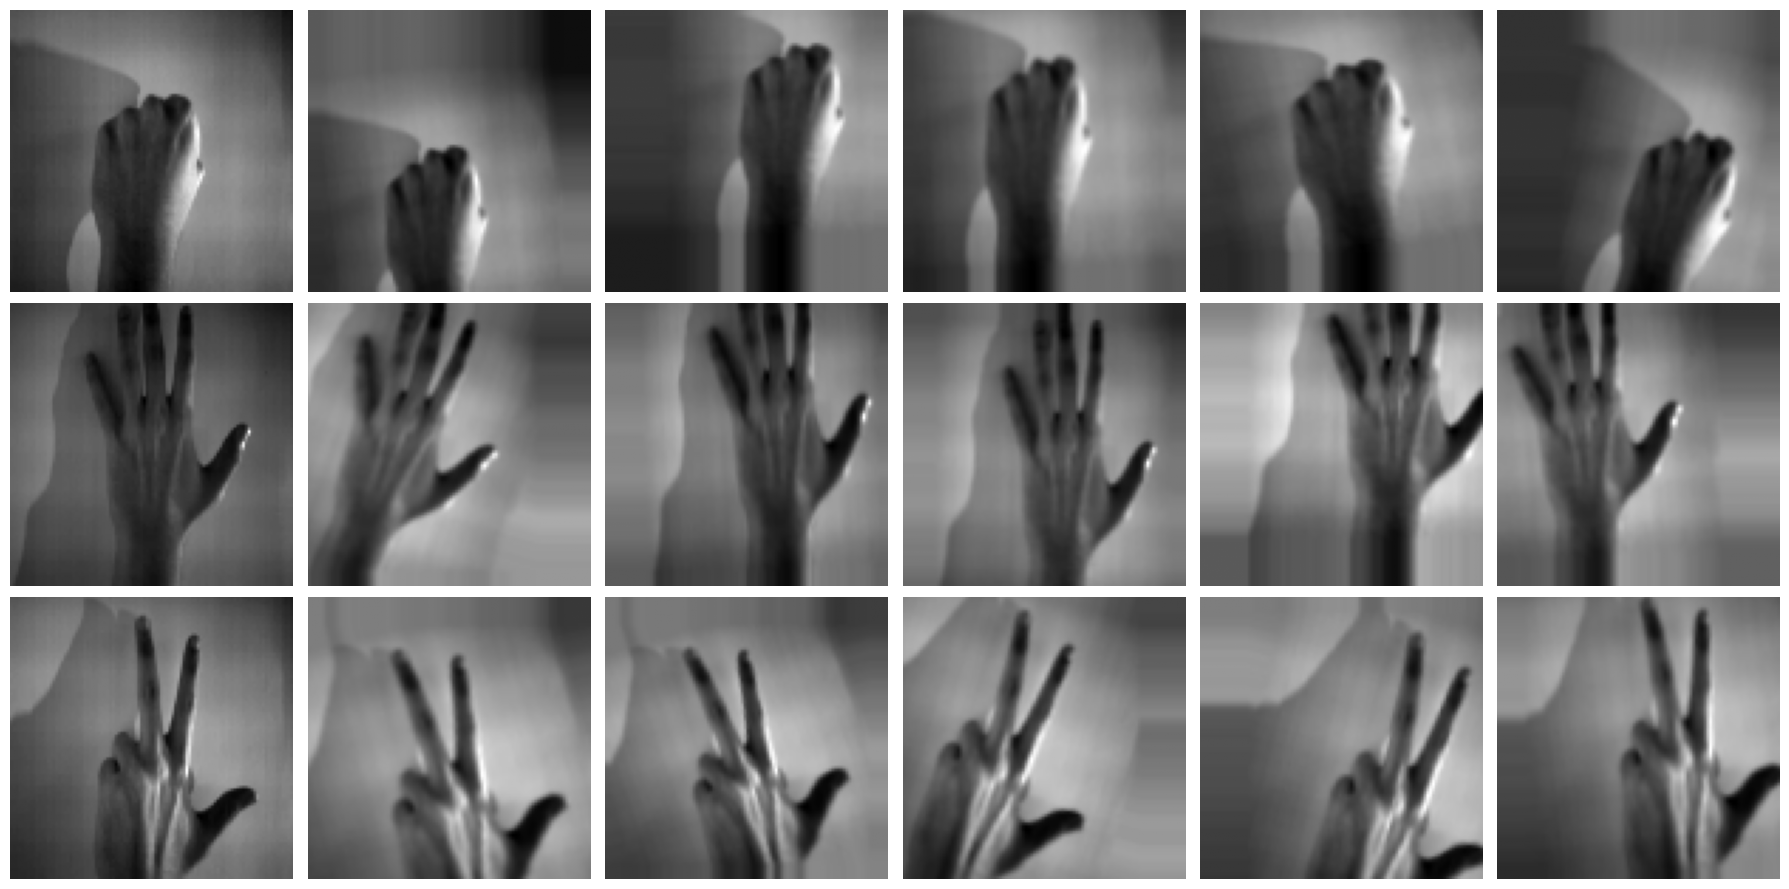

In [9]:
image_categories = [rock_images, paper_images, scissors_images]
num_images = AUGMENTED_COMPARISON_IMAGES + 1

#Create a grid: 3 rows, N columns
fig, axs = plt.subplots(3, AUGMENTED_COMPARISON_IMAGES + 1, figsize=(num_images * 3, 9))

for row_idx, images in enumerate(image_categories):
    for col_idx in range(num_images):
        ax = axs[row_idx, col_idx] #Access specific row and column
        
        #Display the image
        ax.imshow(images[col_idx], cmap='gray')
            
        ax.axis('off')

plt.tight_layout()
plt.show()

In [10]:
X_train, Y_train = generate_augmented(train_images, AUGMENT_PER_SOURCE_IMG)
X_test,  Y_test  = generate_augmented(test_images,  AUGMENT_PER_TEST_IMG)   #test = originals + few number of their augmented variants

#Shuffle training set
perm = np.random.permutation(len(X_train))
X_train, Y_train = X_train[perm], Y_train[perm]

TF Datasets

In [11]:
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, Y_train))
    .shuffle(buffer_size=len(X_train), seed=SEED)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, Y_test))
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)

Model Design

In [12]:
import keras
@keras.saving.register_keras_serializable()
def fake_q07(x):
    x_clip = tf.clip_by_value(x, -1.0, 127.0/128.0)
    x_q = tf.round(x_clip * 128.0) / 128.0
    return x_clip + tf.stop_gradient(x_q - x_clip)

inputs = tf.keras.Input(shape=(IMG_H, IMG_W, 1), dtype=tf.float32)
x = data_augmentation(inputs)

#Comments hosws output sizes
x = layers.AveragePooling2D(2)(x)               #50×50×1
#Output Dimension: floor((input dim + 2*padding - (kernel size - 1))/stride + 1)
x = layers.Conv2D(filters = 8,  kernel_size = 3, strides = (1,1), padding="valid", use_bias = True, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)    #48x48x8
#x = layers.BatchNormalization()(x)
x = layers.ReLU(max_value=127.0/128.0)(x)
x = layers.Lambda(fake_q07)(x)
x = layers.MaxPooling2D(2)(x)   #24x24x8                  
x = layers.Lambda(fake_q07)(x)

x = layers.Conv2D(filters = 32, kernel_size = 3, strides = (1,1), padding="valid", use_bias = True, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)    #22x22x32
#x = layers.BatchNormalization()(x)
x = layers.ReLU(max_value=127.0/128.0)(x)
x = layers.Lambda(fake_q07)(x)
x = layers.MaxPooling2D(2)(x)   #11×11×32                   
x = layers.Lambda(fake_q07)(x)
x = layers.Conv2D(filters = 64, kernel_size = 3, strides = (1,1), padding="valid", use_bias = True, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)   #9x9x64     
#x = layers.BatchNormalization()(x)
x = layers.ReLU(max_value=127.0/128.0)(x)
x = layers.Lambda(fake_q07)(x)

x = layers.MaxPooling2D(2)(x)   #4×4×64
x = layers.Lambda(fake_q07)(x)
x = layers.MaxPooling2D(2)(x)   #2×2×64     
x = layers.Lambda(fake_q07)(x)            
x = layers.MaxPooling2D(2)(x)   #1×1×64      
x = layers.Lambda(fake_q07)(x)             
x = layers.Flatten()(x)

x = layers.Dropout(0.3)(x)
x = layers.Dense(32)(x)                         #64×32 = 2048
x = layers.ReLU(max_value=127.0/128.0)(x)
x = layers.Lambda(fake_q07)(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(3)(x)      #3 outputs
                            #2048 * 3 = 6144
outputs = layers.Activation("softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)
model.summary() #Prints a lot of stuff. Commenting out for now because my scroll wheel is meh

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 100, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 100, 100, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 50, 50, 1)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 48, 48, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 48, 48, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 24, 24, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 32)     │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_4 (Lambda)               │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_5 (Lambda)               │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_6 (Lambda)               │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_7 (Lambda)               │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 23,091 (90.20 KB)

 Trainable params: 23,091 (90.20 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4),
]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds,
    callbacks=callbacks,
)

Epoch 1/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.5253 - loss: 0.9219 - val_accuracy: 0.8053 - val_loss: 0.4726 - learning_rate: 0.0010
Epoch 2/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8679 - loss: 0.3909 - val_accuracy: 0.9934 - val_loss: 0.1293 - learning_rate: 0.0010
Epoch 3/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9520 - loss: 0.1820 - val_accuracy: 1.0000 - val_loss: 0.0728 - learning_rate: 0.0010
Epoch 4/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9729 - loss: 0.1136 - val_accuracy: 1.0000 - val_loss: 0.0256 - learning_rate: 0.0010
Epoch 5/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9835 - loss: 0.0740 - val_accuracy: 1.0000 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 6/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9882 - loss: 0.0599 - val_accuracy: 1.0000 - val_loss: 0.0209 - learning_rate: 0.0010
Epoch 7/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9894 - loss: 0.0529 - val_acc

Save model

In [14]:
model.save(MODEL_PATH)
print("Saved:", MODEL_PATH)

model.evaluate(test_ds)

Saved: rps_gray100_savedmodelv3.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0728


[0.07280286401510239, 1.0]